In [1]:
import pandas as pd
dataset = pd.read_parquet("../private/echotypes_classified.parquet")

X, y = dataset[["channel_0_Sv", "channel_1_Sv", "channel_2_Sv"]], dataset["echoclass_id"]
echotype_ids = dataset["echotype_id"]

### Test 1 - Gaussian Naive Bayes pipeline

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from escore.estimators.transformers import SvDifferenceExtractor

pipe_GNB = Pipeline([
    ("features", SvDifferenceExtractor(0)),
    ("clf", GaussianNB())
])

In [3]:
from sklearn.model_selection import cross_validate, GroupKFold

# Estimate accuracy using grouped cross-validation
cv = GroupKFold(n_splits=5)
cv_results = cross_validate(
    pipe_GNB,
    X,
    y,
    cv=cv,
    groups=echotype_ids
)
test_scores = cv_results["test_score"]
print(f"Accuracy on 5-Fold CV: {test_scores.mean():.3f} ± {test_scores.std():.3f}")

# Fit on whole training data
pipe_GNB.fit(X, y)

Accuracy on 5-Fold CV: 0.778 ± 0.149


,steps,"[('features', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,ref_channel_idx,0
,priors,None
,var_smoothing,1e-09


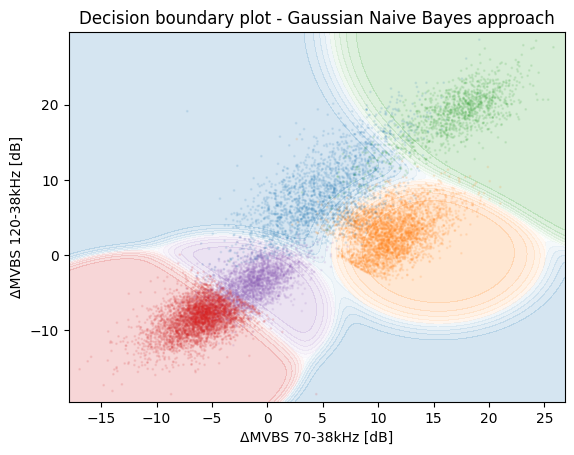

In [5]:
# Decision boundary plot
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import matplotlib as mpl

preprocessor = pipe_GNB['features'] # type: ignore
classifier = pipe_GNB['clf'] # type: ignore

X_preproc = preprocessor.transform(X)

fig, ax = plt.subplots()
display = DecisionBoundaryDisplay.from_estimator(
    classifier,
    X=X_preproc,
    grid_resolution=1000,
    response_method="predict_proba",
    alpha=0.2,
    ax=ax
)
cmap = mpl.colors.ListedColormap(display.multiclass_colors_) # type: ignore
ax.scatter(X_preproc[:, 0], X_preproc[:, 1], s=1, c=y.astype(int), cmap=cmap, alpha=1e-1)

ax.set_xlabel("ΔMVBS 70-38kHz [dB]")
ax.set_ylabel("ΔMVBS 120-38kHz [dB]")
ax.set_title("Decision boundary plot - Gaussian Naive Bayes approach");

**Experiment conclusion:** The experiment show that GaussianNB can predict correclty on our data. However, we need more control, such as implementing the $E_{\text{threshold}}$ and $Q_{\text{threshold}}$ parameters.